In [1]:
import random
import time

# GENERATORY GRAFÓW

def generate_random_graph(n, p=0.2, seed=123):
    rng = random.Random(seed)
    graph = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(i + 1, n):
            if rng.random() < p:
                graph[i].append(j)
                graph[j].append(i)
    return graph

def generate_bipartite_graph(n, p=0.2, seed=123):
    rng = random.Random(seed)
    graph = {i: [] for i in range(n)}
    mid = n // 2
    for u in range(mid):
        for v in range(mid, n):
            if rng.random() < p:
                graph[u].append(v)
                graph[v].append(u)
    return graph

def generate_complete_graph(n):
    graph = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(n):
            if i != j:
                graph[i].append(j)
    return graph

def count_edges(graph):
    return sum(len(neighbors) for neighbors in graph.values()) // 2

# PRZYGOTOWANIE LISTY GRAFÓW

graphs = [
    ("losowy_10", generate_random_graph(10, seed=101)),
    ("losowy_25", generate_random_graph(25, seed=102)),
    ("losowy_50", generate_random_graph(50, seed=103)),
    ("losowy_100", generate_random_graph(100, seed=104)),
    ("losowy_500", generate_random_graph(500, seed=105)),
    ("losowy_1000", generate_random_graph(1000, seed=106)),
    ("losowy_2000", generate_random_graph(2000, seed=107)),

    ("dwudzielny_10", generate_bipartite_graph(10, seed=201)),
    ("dwudzielny_25", generate_bipartite_graph(25, seed=202)),
    ("dwudzielny_50", generate_bipartite_graph(50, seed=203)),
    ("dwudzielny_100", generate_bipartite_graph(100, seed=204)),
    ("dwudzielny_500", generate_bipartite_graph(500, seed=205)),
    ("dwudzielny_1000", generate_bipartite_graph(1000, seed=206)),
    ("dwudzielny_2000", generate_bipartite_graph(2000, seed=207)),

    ("pelny_10", generate_complete_graph(10)),
    ("pelny_25", generate_complete_graph(25)),
    ("pelny_50", generate_complete_graph(50)),
    ("pelny_100", generate_complete_graph(100)),
    ("pelny_500", generate_complete_graph(500)),
    ("pelny_1000", generate_complete_graph(1000)),
    ("pelny_2000", generate_complete_graph(2000)),
]

# WYŚWIETLANIE PARAMETRÓW

print("GRAFY TESTOWE — PARAMETRY\n")

for name, graph in graphs:
    n = len(graph)
    m = count_edges(graph)

    print(f"{name}")
    print(f"  liczba wierzchołków (n): {n}")
    print(f"  liczba krawędzi (m): {m}\n")

GRAFY TESTOWE — PARAMETRY

losowy_10
  liczba wierzchołków (n): 10
  liczba krawędzi (m): 11

losowy_25
  liczba wierzchołków (n): 25
  liczba krawędzi (m): 52

losowy_50
  liczba wierzchołków (n): 50
  liczba krawędzi (m): 241

losowy_100
  liczba wierzchołków (n): 100
  liczba krawędzi (m): 974

losowy_500
  liczba wierzchołków (n): 500
  liczba krawędzi (m): 24997

losowy_1000
  liczba wierzchołków (n): 1000
  liczba krawędzi (m): 99914

losowy_2000
  liczba wierzchołków (n): 2000
  liczba krawędzi (m): 399307

dwudzielny_10
  liczba wierzchołków (n): 10
  liczba krawędzi (m): 6

dwudzielny_25
  liczba wierzchołków (n): 25
  liczba krawędzi (m): 35

dwudzielny_50
  liczba wierzchołków (n): 50
  liczba krawędzi (m): 132

dwudzielny_100
  liczba wierzchołków (n): 100
  liczba krawędzi (m): 509

dwudzielny_500
  liczba wierzchołków (n): 500
  liczba krawędzi (m): 12470

dwudzielny_1000
  liczba wierzchołków (n): 1000
  liczba krawędzi (m): 50069

dwudzielny_2000
  liczba wierzchołków (

In [1]:
# GREEDY

def first_available(used_colors):
    color = 0
    while color in used_colors:
        color += 1
    return color

def greedy_coloring(graph, order):
    coloring = {}

    for vertex in order:
        used_colors = set()
        for neighbor in graph[vertex]:
            if neighbor in coloring:
                used_colors.add(coloring[neighbor])
        coloring[vertex] = first_available(used_colors)

    return coloring

In [3]:
def is_proper_coloring(graph, coloring):
    for v, neighbors in graph.items():
        for u in neighbors:
            if v in coloring and u in coloring and coloring[v] == coloring[u]:
                return False
    return True

In [4]:
# POMIARY DLA GREEDY

REPEATS = 10
print("WYNIKI ALGORYTMU GREEDY\n")

for name, graph in graphs:
    # Stała kolejność dla Greedy (naturalna: 0, 1, 2...)
    order = list(graph.keys())
    times = []

    # Wykonujemy raz, aby pobrać wyniki i sprawdzić poprawność
    coloring = greedy_coloring(graph, order)
    num_colors = len(set(coloring.values()))
    ok = is_proper_coloring(graph, coloring)

    # Pętla pomiarowa (uśrednianie czasu)
    for _ in range(REPEATS):
        start = time.perf_counter()
        greedy_coloring(graph, order)
        end = time.perf_counter()
        times.append(end - start)

    avg_time = sum(times) / REPEATS

    print(f"{name}:")
    print(f"  Liczba kolorów: {num_colors}")
    print(f"  Średni czas ({REPEATS} prób): {avg_time:.8f} s")
    print(f"  Poprawność: {ok}")
    print("-" * 30)

WYNIKI ALGORYTMU GREEDY

losowy_10:
  Liczba kolorów: 3
  Średni czas (10 prób): 0.00000463 s
  Poprawność: True
------------------------------
losowy_25:
  Liczba kolorów: 5
  Średni czas (10 prób): 0.00001235 s
  Poprawność: True
------------------------------
losowy_50:
  Liczba kolorów: 7
  Średni czas (10 prób): 0.00004379 s
  Poprawność: True
------------------------------
losowy_100:
  Liczba kolorów: 11
  Średni czas (10 prób): 0.00023827 s
  Poprawność: True
------------------------------
losowy_500:
  Liczba kolorów: 33
  Średni czas (10 prób): 0.00309980 s
  Poprawność: True
------------------------------
losowy_1000:
  Liczba kolorów: 54
  Średni czas (10 prób): 0.01371561 s
  Poprawność: True
------------------------------
losowy_2000:
  Liczba kolorów: 92
  Średni czas (10 prób): 0.05298649 s
  Poprawność: True
------------------------------
dwudzielny_10:
  Liczba kolorów: 2
  Średni czas (10 prób): 0.00000293 s
  Poprawność: True
------------------------------
dwudzieln

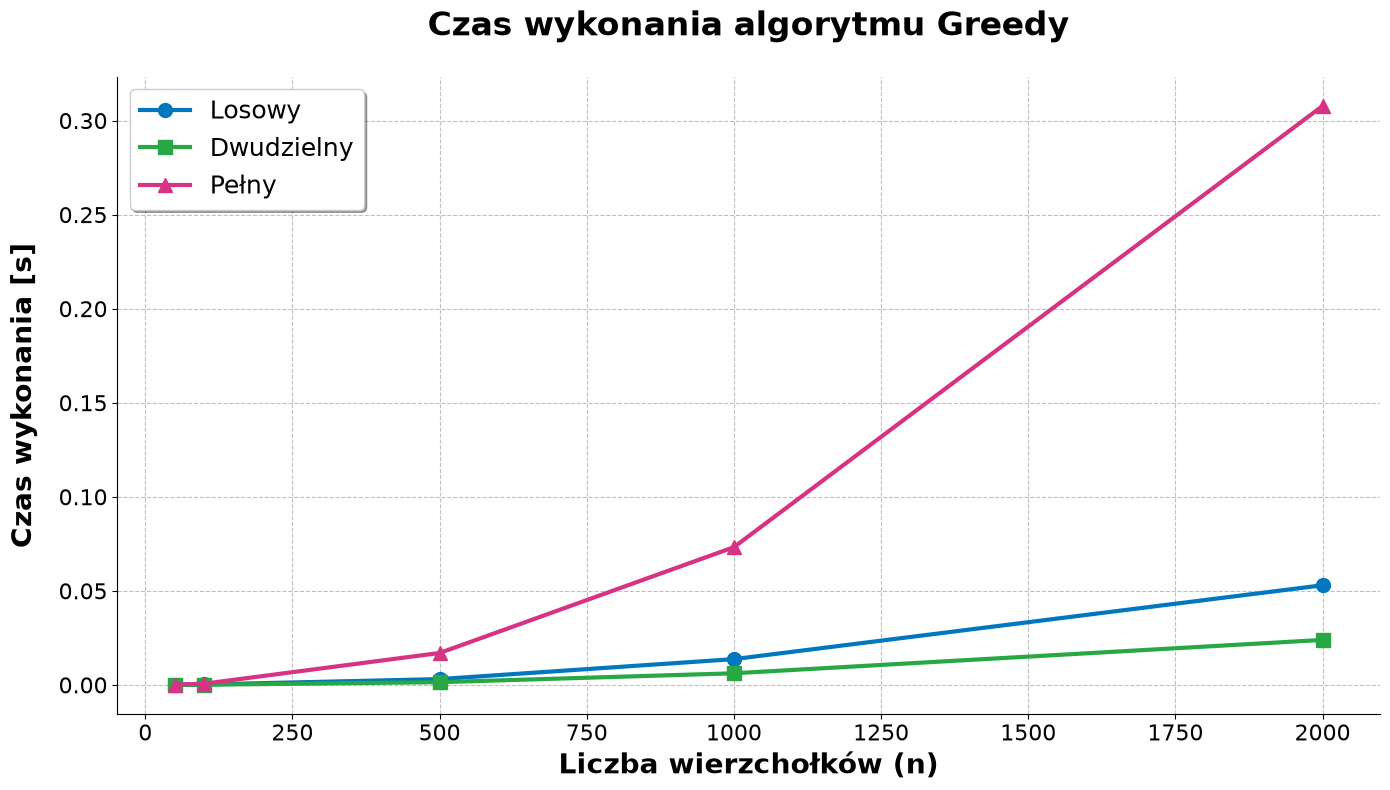

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dane 
n = [50, 100, 500, 1000, 2000]
greedy_czasy_losowy = [0.00004379, 0.00023827, 0.00309980, 0.01371561, 0.05298649]
greedy_czasy_dwudzielny = [0.00002344, 0.00010982, 0.00145017, 0.00618743, 0.02392634]
greedy_czasy_pelny = [0.00017083, 0.00065821, 0.01698230, 0.07323432, 0.30779357]

plt.style.use('default')
fig, ax = plt.subplots(figsize=(14, 8))

# Rysowanie linii z kolorami: Niebieski (#0077be), Zielony (#28a745), Różowy (#d63384)
ax.plot(n, greedy_czasy_losowy, label='Losowy', marker='o', markersize=10, color='#0077be', linewidth=3)
ax.plot(n, greedy_czasy_dwudzielny, label='Dwudzielny', marker='s', markersize=10, color='#28a745', linewidth=3)
ax.plot(n, greedy_czasy_pelny, label='Pełny', marker='^', markersize=10, color='#d63384', linewidth=3)

ax.set_xlabel('Liczba wierzchołków (n)', fontsize=20, fontweight='bold')
ax.set_ylabel('Czas wykonania [s]', fontsize=20, fontweight='bold', labelpad=15)
ax.set_title('Czas wykonania algorytmu Greedy', fontsize=24, fontweight='bold', pad=30)

# Oś X i Y
ax.tick_params(axis='both', labelsize=16)

# Legenda
ax.legend(fontsize=18, frameon=True, shadow=True)

# Siatka
ax.grid(True, which="both", ls="--", color='gray', alpha=0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [3]:
# WELSH-POWELL

def welsh_powell_coloring(graph):
    # 1. Sortowanie wierzchołków malejąco według stopnia
    order = sorted(graph, key=lambda v: len(graph[v]), reverse=True)

    coloring = {}

    for vertex in order:
        used_colors = set()
        # Sprawdzamy kolory sąsiadów
        for neighbor in graph[vertex]:
            if neighbor in coloring:
                used_colors.add(coloring[neighbor])

        # Nadajemy najmniejszy dostępny kolor
        coloring[vertex] = first_available(used_colors)

    return coloring

In [7]:
# POMIARY DLA WELSH-POWELL

print("WYNIKI ALGORYTMU WELSH-POWELL\n")

for name, graph in graphs:
    times_wp = []

    # Wykonujemy raz, aby pobrać wyniki i sprawdzić poprawność
    coloring_wp = welsh_powell_coloring(graph)
    num_colors_wp = len(set(coloring_wp.values()))
    ok_wp = is_proper_coloring(graph, coloring_wp)

    # Pętla pomiarowa (uśrednianie czasu)
    for _ in range(REPEATS):
        start = time.perf_counter()
        welsh_powell_coloring(graph)
        end = time.perf_counter()
        times_wp.append(end - start)

    avg_time_wp = sum(times_wp) / REPEATS

    print(f"{name}:")
    print(f"   Liczba kolorów: {num_colors_wp}")
    print(f"   Średni czas ({REPEATS} prób): {avg_time_wp:.8f} s")
    print(f"   Poprawność: {ok_wp}")
    print("-" * 30)

WYNIKI ALGORYTMU WELSH-POWELL

losowy_10:
   Liczba kolorów: 3
   Średni czas (10 prób): 0.00001002 s
   Poprawność: True
------------------------------
losowy_25:
   Liczba kolorów: 4
   Średni czas (10 prób): 0.00001587 s
   Poprawność: True
------------------------------
losowy_50:
   Liczba kolorów: 6
   Średni czas (10 prób): 0.00004832 s
   Poprawność: True
------------------------------
losowy_100:
   Liczba kolorów: 9
   Średni czas (10 prób): 0.00016546 s
   Poprawność: True
------------------------------
losowy_500:
   Liczba kolorów: 30
   Średni czas (10 prób): 0.00366117 s
   Poprawność: True
------------------------------
losowy_1000:
   Liczba kolorów: 51
   Średni czas (10 prób): 0.01438460 s
   Poprawność: True
------------------------------
losowy_2000:
   Liczba kolorów: 88
   Średni czas (10 prób): 0.05703914 s
   Poprawność: True
------------------------------
dwudzielny_10:
   Liczba kolorów: 2
   Średni czas (10 prób): 0.00000439 s
   Poprawność: True
-----------

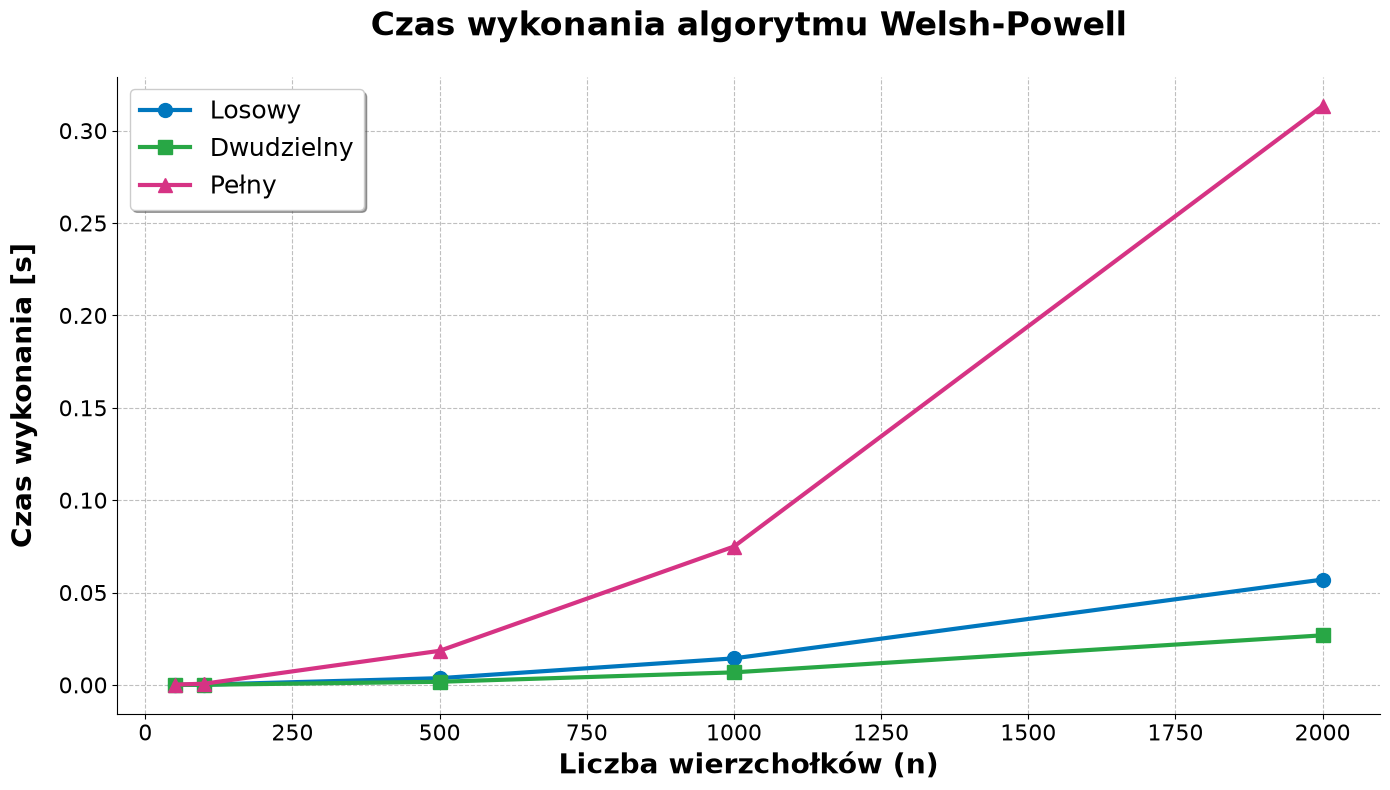

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dane
n = [50, 100, 500, 1000, 2000]
wp_czasy_losowy = [0.00004832, 0.00016546, 0.00366117, 0.01438460, 0.05703914]
wp_czasy_dwudzielny = [0.00003201, 0.00008711, 0.00170792, 0.00681199, 0.02686147]
wp_czasy_pelny = [0.00018342, 0.00066642, 0.01846747, 0.07490672, 0.31338544]

plt.style.use('default')
fig, ax = plt.subplots(figsize=(14, 8))

# Rysowanie linii z kolorami: Niebieski (#0077be), Zielony (#28a745), Różowy (#d63384)
ax.plot(n, wp_czasy_losowy, label='Losowy', marker='o', markersize=10, color='#0077be', linewidth=3)
ax.plot(n, wp_czasy_dwudzielny, label='Dwudzielny', marker='s', markersize=10, color='#28a745', linewidth=3)
ax.plot(n, wp_czasy_pelny, label='Pełny', marker='^', markersize=10, color='#d63384', linewidth=3)

ax.set_xlabel('Liczba wierzchołków (n)', fontsize=20, fontweight='bold')
ax.set_ylabel('Czas wykonania [s]', fontsize=20, fontweight='bold', labelpad=15)
ax.set_title('Czas wykonania algorytmu Welsh-Powell', fontsize=24, fontweight='bold', pad=30)

# Oś X i Y
ax.tick_params(axis='both', labelsize=16)

# Legenda
ax.legend(fontsize=18, frameon=True, shadow=True)

# Siatka
ax.grid(True, which="both", ls="--", color='gray', alpha=0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
# DSATUR

def dsatur_coloring(graph):
    n = len(graph)
    coloring = {}

    # degrees: stopnie wierzchołków (niezmienne)
    degrees = {v: len(neighbors) for v, neighbors in graph.items()}
    # saturation_degrees: liczba RÓŻNYCH kolorów wśród sąsiadów
    saturation_degrees = {v: 0 for v in graph.keys()}

    while len(coloring) < n:
        # 1. Wybór wierzchołka o najwyższym nasyceniu (w razie remisu najwyższy stopień)
        uncolored = [v for v in graph.keys() if v not in coloring]
        u = max(uncolored, key=lambda v: (saturation_degrees[v], degrees[v]))

        # 2. Szukanie kolorów użytych przez sąsiadów
        used_colors = {coloring[neighbor] for neighbor in graph[u] if neighbor in coloring}

        # 3. Funkcja pomocnicza
        coloring[u] = first_available(used_colors)

        # 4. Aktualizacja stopni nasycenia sąsiadów, którzy nie mają jeszcze koloru
        for neighbor in graph[u]:
            if neighbor not in coloring:
                # Obliczamy zbiór kolorów sąsiadów dla danego wierzchołka
                neighbor_used = {coloring[nb] for nb in graph[neighbor] if nb in coloring}
                saturation_degrees[neighbor] = len(neighbor_used)

    return coloring

In [10]:
# POMIARY DLA DSATUR

print("WYNIKI ALGORYTMU DSATUR\n")

for name, graph in graphs:
    times_ds = []

    # Wykonujemy raz dla sprawdzenia wyników
    coloring_ds = dsatur_coloring(graph)
    num_colors_ds = len(set(coloring_ds.values()))
    ok_ds = is_proper_coloring(graph, coloring_ds)

    # Pętla pomiarowa
    for _ in range(REPEATS):
        start = time.perf_counter()
        dsatur_coloring(graph)
        end = time.perf_counter()
        times_ds.append(end - start)

    avg_time_ds = sum(times_ds) / REPEATS

    print(f"{name}:")
    print(f"   Liczba kolorów: {num_colors_ds}")
    print(f"   Średni czas ({REPEATS} prób): {avg_time_ds:.8f} s")
    print(f"   Poprawność: {ok_ds}")
    print("-" * 30)

WYNIKI ALGORYTMU DSATUR

losowy_10:
   Liczba kolorów: 3
   Średni czas (10 prób): 0.00002973 s
   Poprawność: True
------------------------------
losowy_25:
   Liczba kolorów: 4
   Średni czas (10 prób): 0.00012637 s
   Poprawność: True
------------------------------
losowy_50:
   Liczba kolorów: 6
   Średni czas (10 prób): 0.00053890 s
   Poprawność: True
------------------------------
losowy_100:
   Liczba kolorów: 8
   Średni czas (10 prób): 0.00249160 s
   Poprawność: True
------------------------------
losowy_500:
   Liczba kolorów: 28
   Średni czas (10 prób): 0.16521792 s
   Poprawność: True
------------------------------
losowy_1000:
   Liczba kolorów: 48
   Średni czas (10 prób): 1.20849986 s
   Poprawność: True
------------------------------
losowy_2000:
   Liczba kolorów: 82
   Średni czas (10 prób): 9.29319978 s
   Poprawność: True
------------------------------
dwudzielny_10:
   Liczba kolorów: 2
   Średni czas (10 prób): 0.00002790 s
   Poprawność: True
-----------------

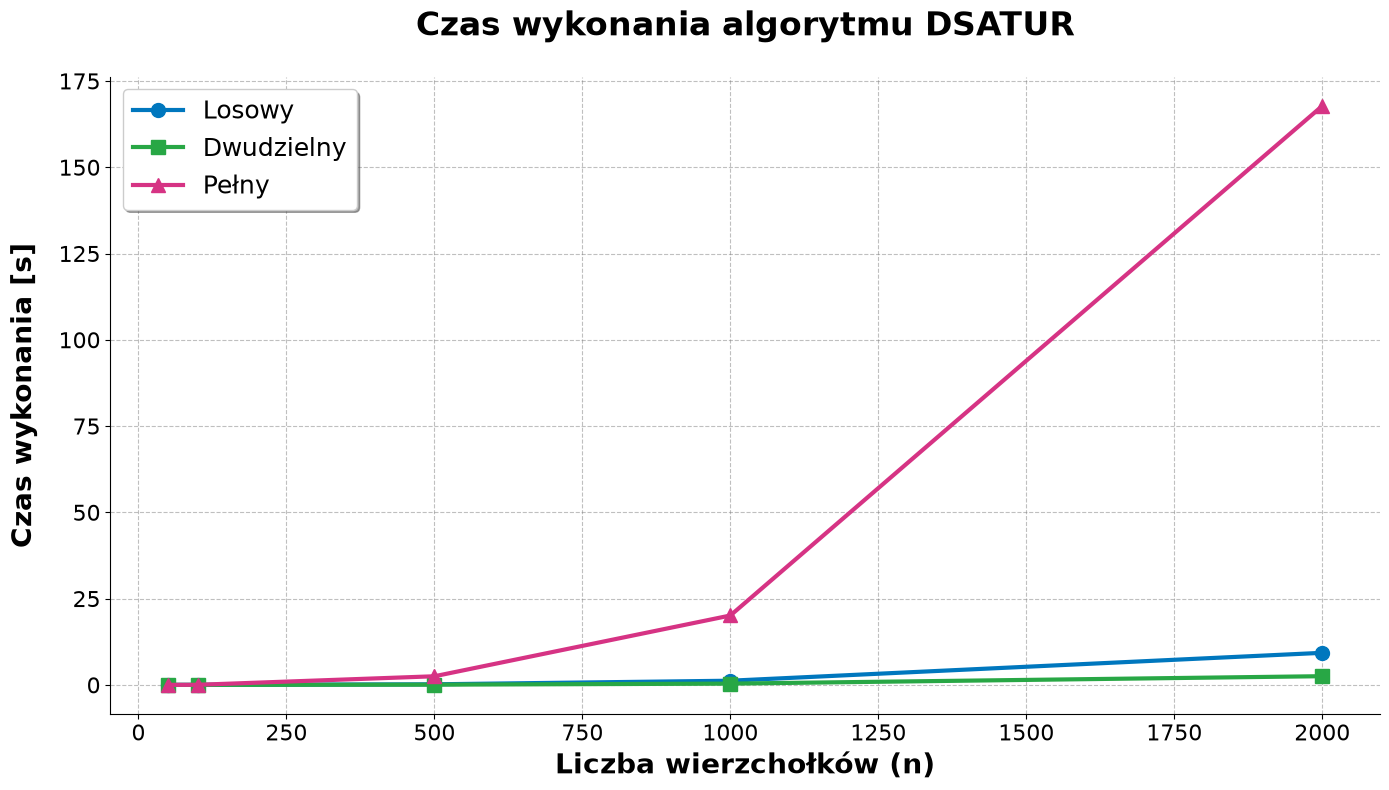

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dane 
n = [50, 100, 500, 1000, 2000]
dsatur_czasy_losowy = [0.00053890, 0.00249160, 0.16521792, 1.20849986, 9.29319978]
dsatur_czasy_dwudzielny = [0.00038435, 0.00158746, 0.06285641, 0.36105894, 2.51813813]
dsatur_czasy_pelny = [0.00328275, 0.02274106, 2.49624293, 20.10801403, 167.76456290]

plt.style.use('default')
fig, ax = plt.subplots(figsize=(14, 8))

# Rysowanie linii z kolorami: Niebieski (#0077be), Zielony (#28a745), Różowy (#d63384)
ax.plot(n, dsatur_czasy_losowy, label='Losowy', marker='o', markersize=10, color='#0077be', linewidth=3)
ax.plot(n, dsatur_czasy_dwudzielny, label='Dwudzielny', marker='s', markersize=10, color='#28a745', linewidth=3)
ax.plot(n, dsatur_czasy_pelny, label='Pełny', marker='^', markersize=10, color='#d63384', linewidth=3)

ax.set_xlabel('Liczba wierzchołków (n)', fontsize=20, fontweight='bold')
ax.set_ylabel('Czas wykonania [s]', fontsize=20, fontweight='bold', labelpad=15)
ax.set_title('Czas wykonania algorytmu DSATUR', fontsize=24, fontweight='bold', pad=30)

# Oś X i Y
ax.tick_params(axis='both', labelsize=16)

# Legenda
ax.legend(fontsize=18, frameon=True, shadow=True)

# Siatka
ax.grid(True, which="both", ls="--", color='gray', alpha=0.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# BACKTRACKING (DOKŁADNY)

def is_safe(v, graph, coloring, c):
    #Sprawdza, czy żaden sąsiad nie ma już koloru c.
    for neighbor in graph[v]:
        if coloring.get(neighbor) == c:
            return False
    return True

def solve_backtracking(graph, k, coloring, v_idx, vertices):
    #Próbuje pokolorować graf używając k kolorów (rekurencyjnie).
    if v_idx == len(vertices):
        return True

    v = vertices[v_idx]
    for c in range(k): # Kolory od 0 do k-1
        if is_safe(v, graph, coloring, c):
            coloring[v] = c
            if solve_backtracking(graph, k, coloring, v_idx + 1, vertices):
                return True
            # Cofnięcie (Backtrack)
            del coloring[v]
    return False

def find_chromatic_number(graph):
    #Szuka najmniejszego k, dla którego backtracking zadziała.
    vertices = list(graph.keys())
    # Próbujemy k = 1, 2, 3... aż do skutku
    for k in range(1, len(vertices) + 1):
        coloring = {}
        if solve_backtracking(graph, k, coloring, 0, vertices):
            return k, coloring
    return len(vertices), {v: i for i, v in enumerate(vertices)}

In [15]:
REPEATS_BT = 10
print("WYNIKI ALGORYTMU BACKTRACKING (DOKŁADNY)\n")

for name, graph in graphs:
    n = len(graph)

    # Ograniczamy do n <= 25
    if n > 25:
        print(f"{name}:")
        print(f"   Status: POMINIĘTO (n > 25 - zbyt duża złożoność dla 10 prób)")
        print("-" * 30)
        continue

    times_bt = []

    # Wykonujemy raz, aby pobrać wyniki i sprawdzić poprawność
    num_colors_bt, coloring_bt = find_chromatic_number(graph)
    ok_bt = is_proper_coloring(graph, coloring_bt)

    # Pętla pomiarowa (uśrednianie czasu)
    for _ in range(REPEATS_BT):
        start = time.perf_counter()
        find_chromatic_number(graph)
        end = time.perf_counter()
        times_bt.append(end - start)

    avg_time_bt = sum(times_bt) / REPEATS_BT

    print(f"{name}:")
    print(f"   Liczba kolorów (Optymalna): {num_colors_bt}")
    print(f"   Średni czas ({REPEATS_BT} prób): {avg_time_bt:.8f} s")
    print(f"   Poprawność: {ok_bt}")
    print("-" * 30)

WYNIKI ALGORYTMU BACKTRACKING (DOKŁADNY)

losowy_10:
   Liczba kolorów (Optymalna): 3
   Średni czas (10 prób): 0.00005540 s
   Poprawność: True
------------------------------
losowy_25:
   Liczba kolorów (Optymalna): 4
   Średni czas (10 prób): 0.13987726 s
   Poprawność: True
------------------------------
losowy_50:
   Status: POMINIĘTO (n > 25 - zbyt duża złożoność dla 10 prób)
------------------------------
losowy_100:
   Status: POMINIĘTO (n > 25 - zbyt duża złożoność dla 10 prób)
------------------------------
losowy_500:
   Status: POMINIĘTO (n > 25 - zbyt duża złożoność dla 10 prób)
------------------------------
losowy_1000:
   Status: POMINIĘTO (n > 25 - zbyt duża złożoność dla 10 prób)
------------------------------
losowy_2000:
   Status: POMINIĘTO (n > 25 - zbyt duża złożoność dla 10 prób)
------------------------------
dwudzielny_10:
   Liczba kolorów (Optymalna): 2
   Średni czas (10 prób): 0.00000874 s
   Poprawność: True
------------------------------
dwudzielny_25:
 

KeyboardInterrupt: 

In [5]:
import random

def generate_bipartite_graph(n, p=0.2, seed=123):
    rng = random.Random(seed)
    graph = {i: [] for i in range(n)}
    mid = n // 2
    for u in range(mid):
        for v in range(mid, n):
            if rng.random() < p:
                graph[u].append(v)
                graph[v].append(u)
    return graph

print("TEST ANOMALII: Welsh-Powell na grafach dwudzielnych")

# Testujemy dla problematycznych rozmiarów
for n_val in [50, 500, 1000, 2000]:
    print(f"\n Wyniki dla n={n_val}")
    print(f"{'Seed':<8} {'Greedy':>8} {'WP':>8} {'Różnica':>10}")

    anomalies_count = 0

    for seed in range(15):
        G = generate_bipartite_graph(n_val, p=0.2, seed=seed)

        order_greedy = list(G.keys())
        
        c_greedy = greedy_coloring(G, order_greedy)
        c_wp = welsh_powell_coloring(G)

        n_greedy = len(set(c_greedy.values()))
        n_wp = len(set(c_wp.values()))
        diff = n_wp - n_greedy

        marker = " <-- ANOMALIA" if diff > 0 else ""
        if diff > 0:
            anomalies_count += 1

        print(f"{seed:<8} {n_greedy:>8} {n_wp:>8} {diff:>+10}{marker}")

    print(f"Podsumowanie dla n={n_val}: Anomalia wystąpiła w {anomalies_count} na 15 przypadków.")

TEST ANOMALII: Welsh-Powell na grafach dwudzielnych

 Wyniki dla n=50
Seed       Greedy       WP    Różnica
0               2        2         +0
1               2        4         +2 <-- ANOMALIA
2               2        5         +3 <-- ANOMALIA
3               2        3         +1 <-- ANOMALIA
4               2        3         +1 <-- ANOMALIA
5               2        4         +2 <-- ANOMALIA
6               2        2         +0
7               2        2         +0
8               2        3         +1 <-- ANOMALIA
9               2        3         +1 <-- ANOMALIA
10              2        2         +0
11              2        3         +1 <-- ANOMALIA
12              2        3         +1 <-- ANOMALIA
13              2        2         +0
14              2        5         +3 <-- ANOMALIA
Podsumowanie dla n=50: Anomalia wystąpiła w 10 na 15 przypadków.

 Wyniki dla n=500
Seed       Greedy       WP    Różnica
0               2        3         +1 <-- ANOMALIA
1               2  

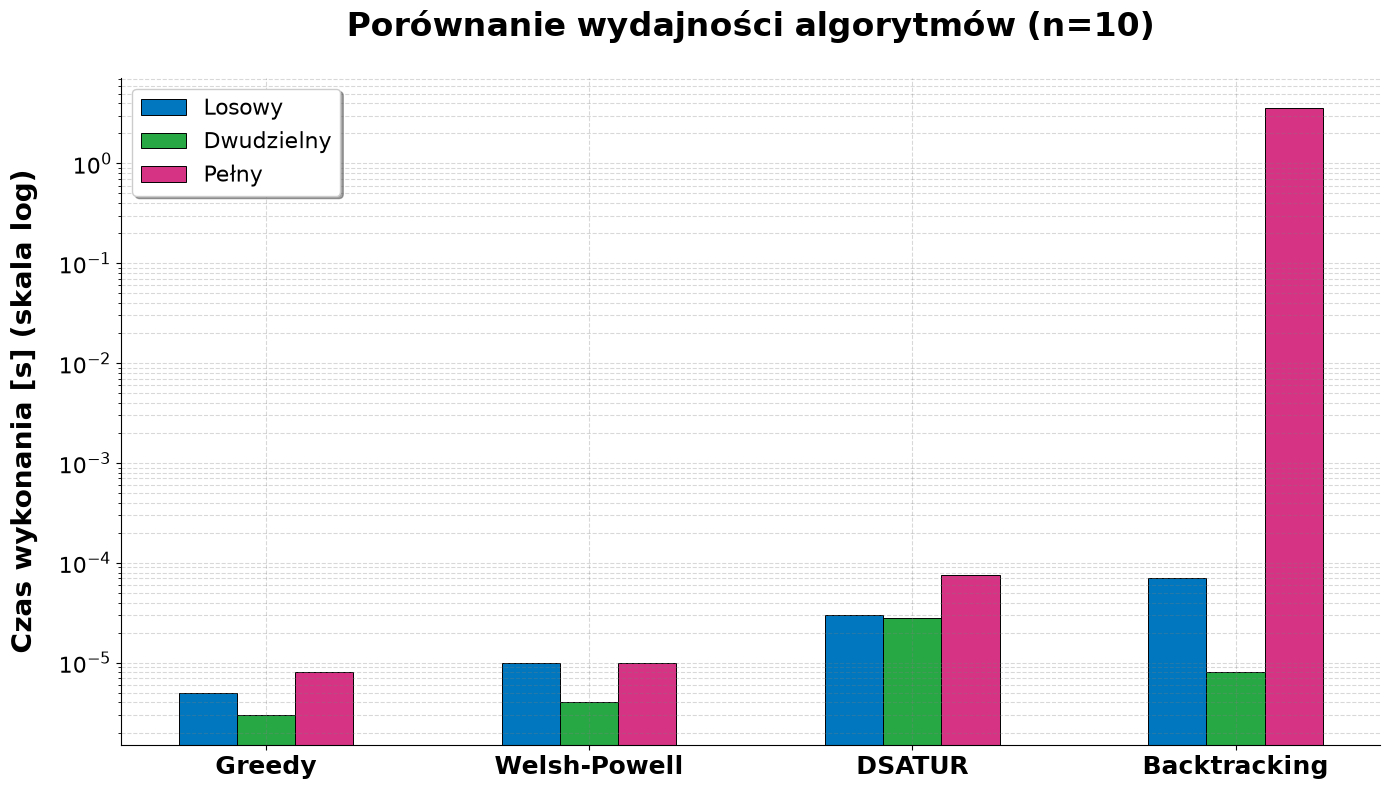

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dane dla n=10
labels = ['Greedy', 'Welsh-Powell', 'DSATUR', 'Backtracking']
losowy = [0.000005, 0.000010, 0.000030, 0.000071]
dwudzielny = [0.000003, 0.000004, 0.000028, 0.000008]
pelny = [0.000008, 0.000010, 0.000076, 3.588949 ]

x = np.arange(len(labels))
width = 0.18 

plt.style.use('default') 
fig, ax = plt.subplots(figsize=(14, 8))

ax.bar(x - width, losowy, width, label='Losowy', color='#0077be', edgecolor='black', linewidth=0.7)
ax.bar(x, dwudzielny, width, label='Dwudzielny', color='#28a745', edgecolor='black', linewidth=0.7)
ax.bar(x + width, pelny, width, label='Pełny', color='#d63384', edgecolor='black', linewidth=0.7)

ax.set_yscale('log')
ax.set_ylabel('Czas wykonania [s] (skala log)', fontsize=20, fontweight='bold', labelpad=15)
ax.set_title('Porównanie wydajności algorytmów (n=10)', fontsize=24, fontweight='bold', pad=30)

# Oś X
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=18, fontweight='bold')

# Oś Y
ax.tick_params(axis='y', labelsize=16)

# Legenda
ax.legend(fontsize=16, frameon=True, shadow=True, loc='upper left')

# Siatka 
ax.grid(True, which="both", ls="--", color='gray', alpha=0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()